In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Kiểm tra thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_pin_memory = True if torch.cuda.is_available() else False

# Tiền xử lý ảnh
tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# DataLoader cho tập huấn luyện
train_dl = DataLoader(
    datasets.ImageFolder('data/Training', transform=tf),
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=use_pin_memory
)

# DataLoader cho tập kiểm thử
test_dl = DataLoader(
    datasets.ImageFolder('data/Testing', transform=tf),
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=use_pin_memory
)

In [2]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 4) # 4 classes
).to(device)

In [3]:
opt = optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

In [4]:
model.train()

for epoch in range(3):
    running_loss = 0.0

    for x, y in train_dl:
        opt.zero_grad()
        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward()
        running_loss += loss.item()
        opt.step()

    print(f"Epoch {epoch+1}: Loss was {running_loss/len(train_dl):.4f}")


Epoch 1: Loss was 0.8652
Epoch 2: Loss was 0.5934
Epoch 3: Loss was 0.5043


In [5]:
# Đặt model sang chế độ đánh giá (evaluation mode)
model.eval()

# Khởi tạo biến để lưu tổng loss và số lượng dự đoán đúng
test_loss, correct = 0.0, 0

# Tắt gradient để tăng tốc và tiết kiệm bộ nhớ khi đánh giá
with torch.no_grad():
    for x, y in test_dl:
        # Chuyển dữ liệu sang thiết bị (CPU hoặc GPU)
        x, y = x.to(device), y.to(device)

        # Tính toán output (logits) từ model
        logits = model(x)

        # Tính loss cho batch hiện tại, nhân với số mẫu trong batch
        test_loss += loss_fn(logits, y).item() * y.size(0)

        # Lấy nhãn dự đoán bằng cách chọn class có giá trị lớn nhất
        preds = logits.argmax(dim=1)

        # Đếm số dự đoán đúng
        correct += (preds == y).sum().item()

# Tính loss trung bình trên toàn bộ dataset test
test_loss /= len(test_dl.dataset)

# Tính độ chính xác (accuracy) theo phần trăm
accuracy = 100.0 * correct / len(test_dl.dataset)

print('Test Loss:', test_loss, 'Test accuracy:', accuracy, '%')


Test Loss: 0.9267258176207542 Test accuracy: 73.1875 %


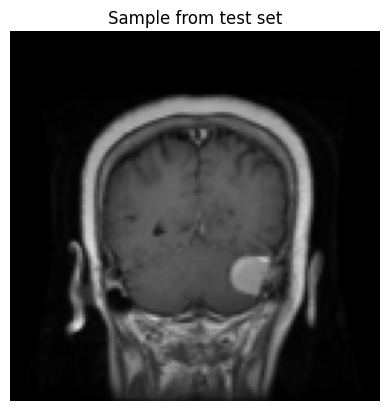

Predicted class: meningioma
Ground-truth: meningioma


In [6]:
import random
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

# Đặt model sang chế độ đánh giá
model.eval()

# Chọn ngẫu nhiên một ảnh từ tập test
idx = random.randrange(len(test_dl.dataset))
img, label = test_dl.dataset[idx]

# "Unnormalize" ảnh để hiển thị đúng màu (vì trước đó Normalize [-1,1])
unnorm = img * 0.5 + 0.5

# Hiển thị ảnh bằng matplotlib
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title('Sample from test set')
plt.show()

# Dự đoán class của ảnh bằng model
with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))  # thêm batch dimension
    pred = logits.argmax(1).item()               # lấy class có xác suất cao nhất

# Lấy tên class từ dataset
class_names = test_dl.dataset.classes

print(f"Predicted class: {class_names[pred]}")
print(f"Ground-truth: {class_names[label]}")
